# Perform Mass Balance Check on ResOPS Reservoir
For each reservoir, check daily differences between inflow-outflow and change in storage

In [1]:
import os
print(f"Current Directory: {os.getcwd()}")
os.chdir("..")
print(f"New Directory: {os.getcwd()}")

Current Directory: c:\Users\mattc\Documents\DL-reservoir-modeling\reviewer_comments
New Directory: c:\Users\mattc\Documents\DL-reservoir-modeling


In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from math import floor
import seaborn as sns
import os
import copy
from tqdm import tqdm
from scipy import stats
from scipy.stats import theilslopes

from src.data.data_processing import *
from src.data.data_fetching import *
from src.models.model_zoo import *
from src.models.predict_model import *
from src.models.train_model import *
from src.data.implied_storage import get_implied_storage
from src.models.analyze_lstm_cell import *
import seaborn as sns

In [3]:
def mass_balance_check(res_id, left_year):
    df = resops_fetch_data(res_id=res_id)[f'{left_year}-01-01':'2020-12-31'].copy()
    df['storage_diff'] = df['storage'].shift(-1) - df['storage'] # change in storage in MCM/day
    df['inflow_outflow_diff'] = (df['inflow'] - df['outflow']) * 60 * 60 * 24 / 1e6 # MCM/day
    df = df.dropna()

    # GRanD Attributes - Get Capacity
    gdf = gpd.read_file("data/GRanD/GRanD_dams_v1_3.shp")
    gdf = gdf.drop(columns="geometry").set_index("GRAND_ID")
    gdf.index = gdf.index.astype(type(res_id))
    capacity = gdf['CAP_MCM'].loc[res_id]

    residual = df['storage_diff'] - df['inflow_outflow_diff']
    corr = df['storage_diff'].corr(df['inflow_outflow_diff'])
    slope = np.polyfit(df['inflow_outflow_diff'], df['storage_diff'], 1)[0]
    mean_error = residual.mean()
    median_error = residual.median()
    std_error = residual.std()
    rmse = np.sqrt((residual**2).mean())

    return {
        'corr': corr,
        'slope': slope,
        'mean_error': mean_error,
        'median_error': median_error,
        'std_error': std_error,
        'rmse': rmse,
        'normalized_mean_error': mean_error / capacity * 100
    }

In [4]:
res_list = sorted(filter_res())
left_years = get_left_years(res_list)

mass_balance_df = pd.DataFrame(index=res_list)
for res_id in tqdm(res_list, 'Calculating correlations'):
    mass_balance_check_i = mass_balance_check(res_id, left_years[res_id])
    mass_balance_df.loc[res_id, ['mass_corr', 'mass_slope', 'mass_mean_error', 'mass_median_error', 'mass_std_error', 'mass_rmse', 'mass_norm_mean_error']] = (mass_balance_check_i['corr'], 
                                                                                                   mass_balance_check_i['slope'], 
                                                                                                   mass_balance_check_i['mean_error'], 
                                                                                                   mass_balance_check_i['median_error'],
                                                                                                   mass_balance_check_i['std_error'],
                                                                                                   mass_balance_check_i['rmse'],
                                                                                                   mass_balance_check_i['normalized_mean_error'])

Calculating correlations: 100%|██████████| 116/116 [00:21<00:00,  5.35it/s]


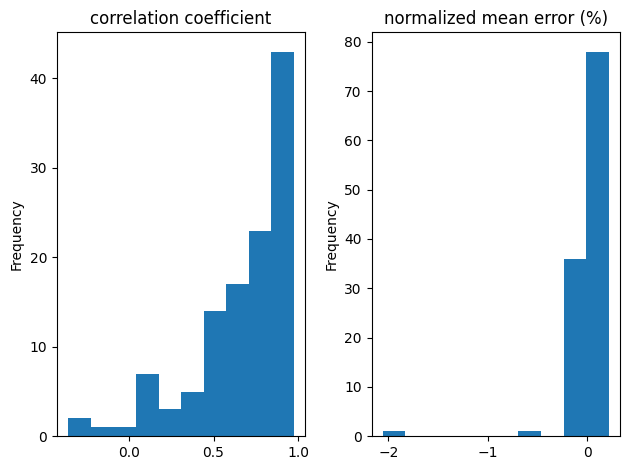

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=2)
mass_balance_df['mass_corr'].plot(kind='hist', ax=axes[0])
mass_balance_df['mass_norm_mean_error'].plot(kind='hist', ax=axes[1])
axes[0].set_title('correlation coefficient')
axes[1].set_title('normalized mean error (%)')
plt.tight_layout()
plt.show()

In [6]:
mass_balance_df[mass_balance_df['mass_norm_mean_error'].abs() > 0.5]

,mass_corr,mass_slope,mass_mean_error,mass_median_error,mass_std_error,mass_rmse,mass_norm_mean_error
204,0.056835,0.025098,-1.735114,-1.728966,1.977359,2.630644,-2.055823
415,0.473542,0.431183,-0.257157,-0.166074,0.713699,0.758591,-0.682115


## How does mass balance error affect results?

In [7]:
# Get linear probe-storage correlations (in test data)
linear_probe_corrs = pd.read_csv('report/results/resops_training/resops_unroll_models/cell_storage_correlations/cell_storage_corr_model1_test.csv', index_col=0).iloc[-1, :]
linear_probe_corrs.name = 'linear_probe_corr'

# Get model test r2 scores
r2_scores = pd.read_csv('report/results/resops_training/resops_individual_r2.csv', index_col=0)
r2_scores.index = r2_scores.index.astype(str)

# Join with mass balance correlations
summary_df = mass_balance_df.join([linear_probe_corrs, r2_scores], how='left')

In [8]:
summary_df[mass_balance_df['mass_norm_mean_error'].abs() > 0.5]

,mass_corr,mass_slope,mass_mean_error,mass_median_error,mass_std_error,mass_rmse,mass_norm_mean_error,linear_probe_corr,train,val,test
204,0.056835,0.025098,-1.735114,-1.728966,1.977359,2.630644,-2.055823,0.670544,0.913555,0.863475,0.488409
415,0.473542,0.431183,-0.257157,-0.166074,0.713699,0.758591,-0.682115,0.890430,0.945534,0.972272,0.863868


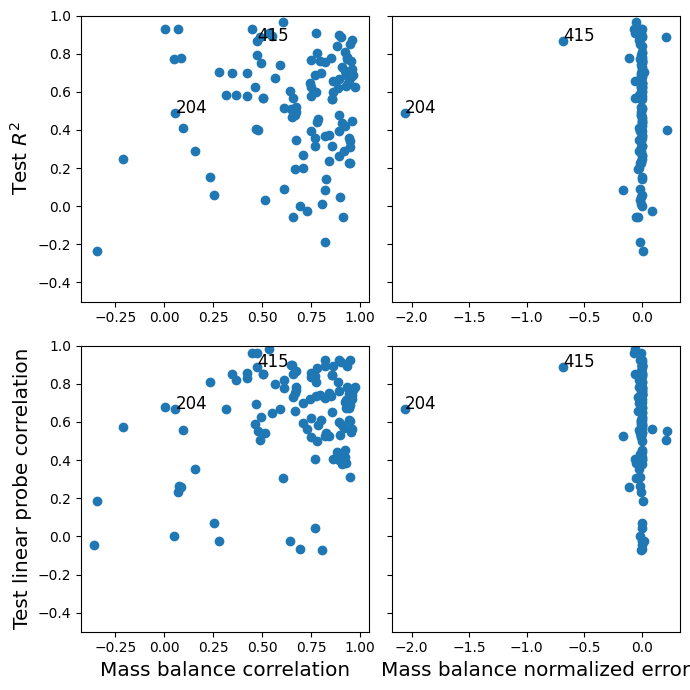

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(7, 7), sharey=True)

ids_to_label = ['204', '415']

axes[0, 0].scatter(summary_df['mass_corr'], summary_df['test'])
axes[0, 0].set_ylim(-0.5, 1)
axes[0, 0].set_ylabel('Test $R^2$', size='x-large')
for id in ids_to_label:
    axes[0, 0].text(summary_df.loc[id, 'mass_corr'], summary_df.loc[id, 'test'], id, size='large')

axes[0, 1].scatter(summary_df['mass_norm_mean_error'], summary_df['test'])
axes[0, 1].set_ylim(-0.5, 1)
for id in ids_to_label:
    axes[0, 1].text(summary_df.loc[id, 'mass_norm_mean_error'], summary_df.loc[id, 'test'], id, size='large')

axes[1, 0].scatter(summary_df['mass_corr'], summary_df['linear_probe_corr'])
axes[1, 0].set_ylabel('Test linear probe correlation', size='x-large')
axes[1, 0].set_xlabel('Mass balance correlation', size='x-large')
for id in ids_to_label:
    axes[1, 0].text(summary_df.loc[id, 'mass_corr'], summary_df.loc[id, 'linear_probe_corr'], id, size='large')


axes[1, 1].scatter(summary_df['mass_norm_mean_error'], summary_df['linear_probe_corr'])
axes[1, 1].set_xlabel('Mass balance normalized error', size='x-large')
for id in ids_to_label:
    axes[1, 1].text(summary_df.loc[id, 'mass_norm_mean_error'], summary_df.loc[id, 'linear_probe_corr'], id, size='large')

plt.tight_layout()
plt.show()

## Compare Implied Storage (from Inflow/Outflow data) to Linear Probe

In [10]:
def get_implied_storage(df):
    """
    Get implied storage time series based on inflow and outflow data, set initial storage to first observed storage.
    """
    implied_storages = [df['storage'].iloc[0]]
    for i in range(1, len(df)):
        implied_storages.append(implied_storages[-1] + (df['inflow'].iloc[i-1] - df['outflow'].iloc[i-1]) * 60 * 60 * 24 / 1e6)
    return implied_storages

In [11]:
def data_processing(id, transform_type, left, right=None, train_frac=0.6, val_frac=0.2, test_frac=0.2, return_scaler=False, storage=False):
    """
    Run data processing pipeline for one ResOPS/USBR reservoir.
    Params:
    id -- str, ResOPS reservoir ID (numeric) or USBR name (character)
    transform_type -- str, in preprocessing, whether to 'standardize' or 'normalize' the data
    left -- str (YYYY-MM-DD), beginning boundary of time window
    right -- str (YYYY-MM-DD), end boundary of time window. By default, '2020-12-31' for ResOPS and '2022-12-31' for USBR
    return_scaler -- bool, whether or not to return src.data.data_processing.time_scaler() object
    storage -- bool, whether or not to include storage data in features
    """

    # Read in data, columns are [inflow, outflow, storage]
    if id.isdigit():
        df = resops_fetch_data(res_id=id, vars=['inflow', 'outflow', 'storage'])
        right = '2020-12-31' if right is None else right # Default right window for ResOPS
    else:
        df = usbr_fetch_data(name=id, vars=['inflow', 'outflow', 'storage'])
        right = '2022-12-31' if right is None else right # Default right window for USBR

    # Add day of the year (doy) as another column
    df['doy'] = df.index.to_series().dt.dayofyear
    # Select data window
    df = df[left:right].copy()

    # Run data processing pipeline
    pipeline = processing_pipeline(train_frac=train_frac, val_frac=val_frac, test_frac=test_frac, chunk_size=3*365, pad_value=-1, transform_type=transform_type, fill_na_method='mean')
    # Train/val/test tensors of shape (#chunks, chunksize, [inflow, outflow, storage, doy])
    ts_train, ts_val, ts_test = pipeline.process_data(df) 

    # Separate inputs(X) and targets (y)
    if storage:
        X_train, X_val, X_test = ts_train[:, :, [0, 2, 3]], ts_val[:, :, [0, 2, 3]], ts_test[:, :, [0, 2, 3]]
    else:
        X_train, X_val, X_test = ts_train[:, :, [0, 3]], ts_val[:, :, [0, 3]], ts_test[:, :, [0, 3]]
    # select outflow as target feature
    y_train, y_val, y_test = ts_train[:, :, [1]], ts_val[:, :, [1]], ts_test[:, :, [1]]

    if return_scaler:
        return (X_train, y_train), (X_val, y_val), (X_test, y_test), pipeline.scaler
    else:
        return (X_train, y_train), (X_val, y_val), (X_test, y_test)

def load_resops_model1(res_id):
    """ 
    Load trained manual unroll LSTM Model 1 for one ResOPS reservoir
    Params:
    res_id -- int, ResOPS reservoir ID
    model_num -- int, which manual unroll model to load (1-4)
    """
    input_size = 2 # inflow, doy
    hidden_size1 = 30
    hidden_size2 = 15
    output_size = 1 # outflow
    dropout_prob = 0.3
    num_layers = 1

    torch.manual_seed(0)
    model = LSTMModel1(input_size=input_size, hidden_size1=hidden_size1, 
                                hidden_size2=hidden_size2, output_size=output_size, num_layers=num_layers, dropout_prob=dropout_prob)
 
    # Load model weights
    model.load_state_dict(torch.load(f'src/models/saved_models/resops_unroll_models/resops_model1_{res_id}.pt', weights_only=True))
    model.eval()
    return model

def get_linear_probe(id, model, left_year, return_data=True):
    """
    Get test period linear-probe series (fit linear probe on train data and return predicted series for test data)
    Params:
    id - str, ResOPS reservoir ID (numeric) or USBR name (character)
    left_year - left and year window for data processing, i.e. for ResOPS from get_left_years(res_list)[res_id]
    """
    # Get split df data (fill NA with training mean)
    df_train, df_val, df_test = split_df_data(id=id, left=f'{left_year}-01-01', data_splits=(0.6, 0.2, 0.2), fill_train_mean=True)
    # Data processing
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = data_processing(id=id, transform_type='standardize',
                                                        left=f'{left_year}-01-01', return_scaler=False, storage=False)

    # Get hidden and cell states, result is list with one tensor for each layer, shape is (# chunks, timesteps, hidden size)
    with torch.no_grad():
        hidden_train, cell_train = model(X_train)[1]
        hidden_val, cell_val = model(X_val)[1]
        hidden_test, cell_test = model(X_test)[1]

    # Fit and predict linear probe
    probe = cell_linear_probe()
    probe.fit_probe(cell_train[0], df_train.storage.values)

    linear_probe_train = probe.predict(cell_train[0])[:len(df_train)]
    linear_probe_val = probe.predict(cell_val[0])[:len(df_val)]
    linear_probe_test = probe.predict(cell_test[0])[:len(df_test)]

    if return_data:
        return (linear_probe_train, linear_probe_val, linear_probe_test), {'df_splits': (df_train, df_val, df_test), 
                                                                           'cell_splits': (cell_train, cell_val, cell_test), 
                                                                           'tensor_splits': (X_train, X_val, X_test, y_train, y_val, y_test)}
    else:
        return (linear_probe_train, linear_probe_val, linear_probe_test)
    


In [12]:
# Get test period implied storage series, correlate with test observed storage
for res_id in tqdm(res_list, 'Calculating test implied storage corrs'):
    df_train, df_val, df_test = split_df_data(id=res_id, left=f'{left_years[res_id]}-01-01', data_splits=(0.6, 0.2, 0.2), fill_train_mean=True)
    implied_storage_test = get_implied_storage(df_test)

    summary_df.loc[res_id, 'implied_storage_corr'] = df_test['storage'].corr(pd.Series(implied_storage_test, index=df_test.index))

Calculating test implied storage corrs: 100%|██████████| 116/116 [00:03<00:00, 29.61it/s]


In [13]:
summary_df[summary_df['linear_probe_corr'] > summary_df['implied_storage_corr']].sort_values('linear_probe_corr', ascending=False).head()

,mass_corr,mass_slope,mass_mean_error,mass_median_error,mass_std_error,mass_rmse,mass_norm_mean_error,linear_probe_corr,train,val,test,implied_storage_corr
1883,0.533338,0.533232,-0.430524,-0.432140,2.475131,2.512208,-0.059154,0.984379,0.956038,0.968840,0.909732,0.015015
1192,0.446606,0.478222,-0.593998,-0.481939,5.156610,5.190535,-0.063782,0.963649,0.974757,0.977716,0.930236,0.389612
1122,0.471873,0.472801,-0.012991,-0.019690,3.892494,3.892383,-0.004748,0.961083,0.778982,0.853477,0.792157,0.918485
898,0.949986,0.963042,-0.102072,-0.074858,1.274316,1.278352,-0.018214,0.925089,0.836472,0.850251,0.850579,0.794386
1796,0.644892,0.644902,-0.051052,-0.036330,8.454333,8.454186,-0.002514,0.898681,0.815191,0.744756,0.509386,0.771187


In [17]:
print(sum(summary_df['linear_probe_corr'] > summary_df['implied_storage_corr']))
print(len(summary_df))

34
116


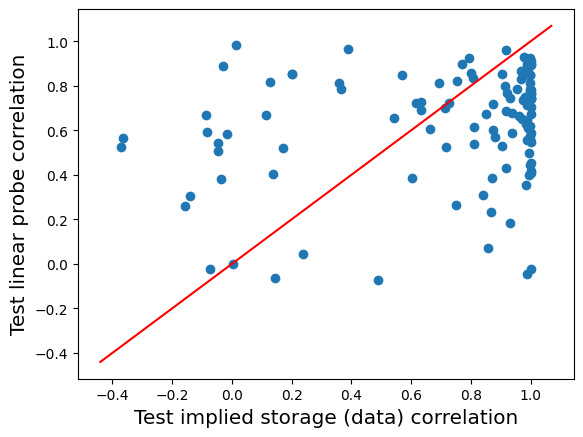

In [14]:
plt.scatter(summary_df['implied_storage_corr'], summary_df['linear_probe_corr'])
lims = [
    min(plt.xlim()[0], plt.ylim()[0]),
    max(plt.xlim()[1], plt.ylim()[1]),
]
plt.plot(lims, lims, c='red')
plt.ylabel('Test linear probe correlation', size='x-large')
plt.xlabel('Test implied storage (data) correlation', size='x-large')
plt.show()

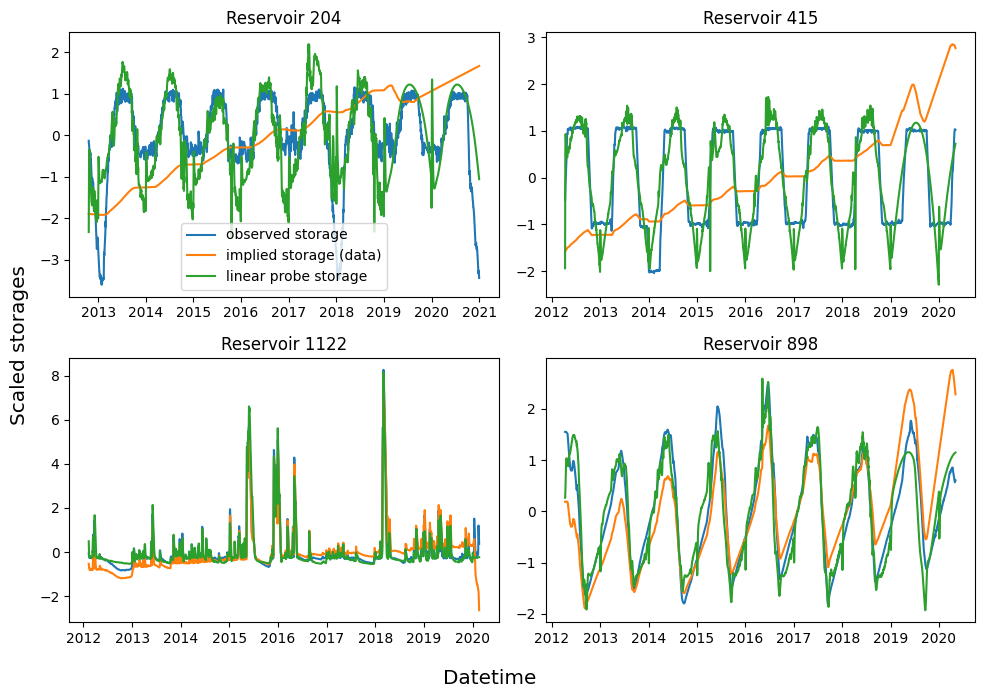

In [15]:
ids_to_plot = ['204', '415', '1122', '898']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 7))
axes = axes.flat

for i, res_id in enumerate(ids_to_plot):
    ax = axes[i]

    (linear_probe_train, linear_probe_val, linear_probe_test), data = get_linear_probe(
        id=res_id,
        model=load_resops_model1(res_id=res_id),
        left_year=left_years[res_id]
    )
    df_train, df_val, df_test = data['df_splits']

    implied_storage_test = get_implied_storage(df_test)

    observed = (df_test.storage - df_test.storage.mean()) / df_test.storage.std()
    implied = (np.array(implied_storage_test) - np.mean(implied_storage_test)) / np.std(implied_storage_test)
    probe = (linear_probe_test - linear_probe_test.mean()) / linear_probe_test.std()

    ax.plot(df_test.index, observed, label='observed storage')
    ax.plot(df_test.index, implied, label='implied storage (data)')
    ax.plot(df_test.index, probe, label='linear probe storage')

    ax.set_title(f'Reservoir {res_id}')
    if i==0:
        ax.legend()

for j in range(len(ids_to_plot), len(axes)):
    fig.delaxes(axes[j])

fig.supxlabel('Datetime', size='x-large')
fig.supylabel('Scaled storages', size='x-large')
plt.tight_layout()
plt.show()

## Combined figure

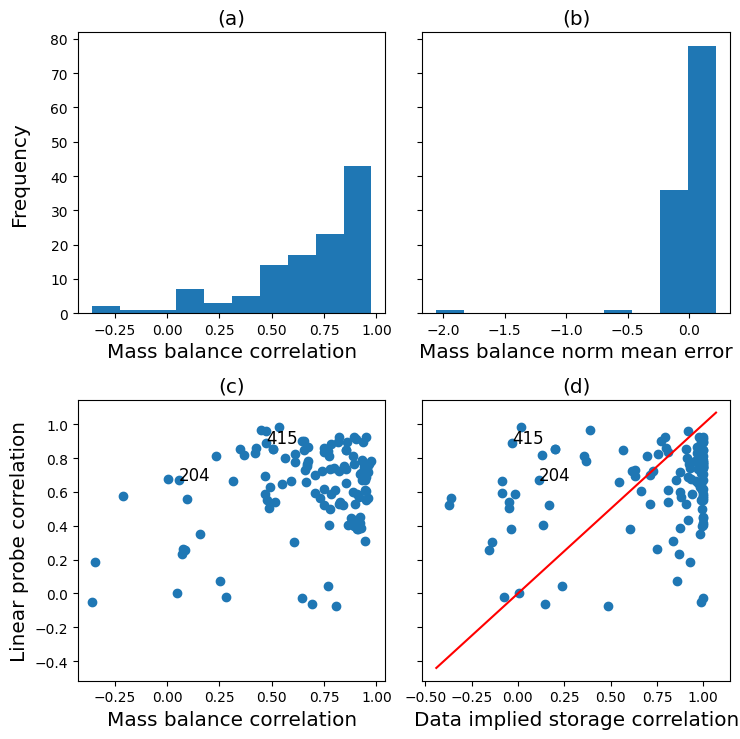

In [42]:
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(7.5, 7.5), sharey='row')

ids_to_label = ['204', '415']

mass_balance_df['mass_corr'].plot(kind='hist', ax=axes[0, 0])
# axes[0, 0].set_title('Mass balance correlation', size='x-large')
axes[0, 0].set_title('(a)', size='x-large')
axes[0, 0].set_xlabel('Mass balance correlation', size='x-large')
axes[0, 0].set_ylabel('Frequency', size='x-large')

mass_balance_df['mass_norm_mean_error'].plot(kind='hist', ax=axes[0, 1])
# axes[0, 1].set_title('Mass balance normalized mean error', size='x-large')
axes[0, 1].set_title('(b)', size='x-large')
axes[0, 1].set_xlabel('Mass balance norm mean error', size='x-large')
# axes[0, 1].set_ylabel('Frequency', size='x-large')

axes[1, 0].scatter(summary_df['mass_corr'], summary_df['linear_probe_corr'])
# axes[1, 0].set_title('Mass balance vs linear probe', size='x-large')
axes[1, 0].set_title('(c)', size='x-large')
axes[1, 0].set_ylabel('Linear probe correlation', size='x-large')
axes[1, 0].set_xlabel('Mass balance correlation', size='x-large')
for id in ids_to_label:
    axes[1, 0].text(summary_df.loc[id, 'mass_corr'], summary_df.loc[id, 'linear_probe_corr'], id, size='large')

axes[1, 1].scatter(summary_df['implied_storage_corr'], summary_df['linear_probe_corr'])
lims = [
    min(plt.xlim()[0], plt.ylim()[0]),
    max(plt.xlim()[1], plt.ylim()[1]),
]
axes[1, 1].plot(lims, lims, c='red')
# axes[1, 1].set_title('Data implied storage vs linear probe', size='x-large')
axes[1, 1].set_title('(d)', size='x-large')
# axes[1, 1].set_ylabel('Test linear probe correlation', size='x-large')
axes[1, 1].set_xlabel('Data implied storage correlation', size='x-large')
for id in ids_to_label:
    axes[1, 1].text(summary_df.loc[id, 'implied_storage_corr'], summary_df.loc[id, 'linear_probe_corr'], id, size='large')

fig.align_ylabels(axes)
plt.tight_layout()
plt.savefig('report/results/reviewer_comments/resops_mass_balance_checks/mass_balance_checks.png', dpi=300, bbox_inches='tight')
plt.show()